<a href="https://colab.research.google.com/github/sadikinisaac/AIML/blob/main/SGcity2graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

city2graph : 0.2.4
geopandas  : 1.1.3
networkx   : 3.6.1

city2graph public API: ['PackageNotFoundError', 'add_metapaths', 'add_metapaths_by_weight', 'base', 'bridge_nodes', 'clip_graph', 'contextlib', 'contiguity_graph', 'create_isochrone', 'create_tessellation', 'data', 'delaunay_graph', 'dual_graph', 'euclidean_minimum_spanning_tree', 'filter_graph_by_distance', 'fixed_radius_graph', 'gabriel_graph', 'gdf_to_nx', 'gdf_to_pyg', 'get_boundaries', 'get_od_pairs', 'graph', 'group_nodes', 'is_torch_available', 'knn_graph', 'load_gtfs', 'load_overture_data', 'metapath', 'mobility', 'morphological_graph', 'morphology', 'nx_to_gdf', 'nx_to_pyg', 'nx_to_rx', 'od_matrix_to_graph', 'plot_graph', 'private_to_private_graph', 'private_to_public_graph', 'process_overture_segments', 'proximity', 'public_to_public_graph', 'pyg_to_gdf', 'pyg_to_nx', 'relative_neighborhood_graph', 'remove_isolated_components', 'rx_to_nx', 'segments_to_graph', 'transportation', 'travel_summary_graph', 'utils', 'validat

✅ Done — top 5 nodes:
         betweenness
node_id             
3416        0.216435
3369        0.212554
3362        0.172852
3363        0.169405
3357        0.167518

Building morphological graph — cbd_marina (r=500m)…
  Calling morphological_graph(distance=500)…



  morpho_nodes keys : ['private', 'public']
  morpho_edges keys : [('private', 'touched_to', 'private'), ('public', 'connected_to', 'public'), ('private', 'faced_to', 'public')]
  Edge counts:
    ('private', 'touched_to', 'private')     → 13656
    ('public', 'connected_to', 'public')     → 0
    ('private', 'faced_to', 'public')        → 0

⚠️  No private→public edges at 500m — retrying at 1000m…
  Calling morphological_graph(distance=1000)…



  morpho_nodes keys : ['private', 'public']
  morpho_edges keys : [('private', 'touched_to', 'private'), ('public', 'connected_to', 'public'), ('private', 'faced_to', 'public')]
  Edge counts:
    ('private', 'touched_to', 'private')     → 0
    ('public', 'connected_to', 'public')     → 19
    ('private', 'faced_to', 'public')        → 0

✅ Morphological graph:
   Private nodes  : 0
   Public nodes   : 14
   Priv→Priv      : 0
   Pub→Pub        : 19
   Priv→Pub       : 0
   TOTAL nodes    : 14
   TOTAL edges    : 19

🏙 Building height analysis:
   Column        : 'height'
   High (>30m)   : 179  HDB towers / condos
   Mid (10–30m)  : 489  shophouses / walkups
   Low (≤10m)    : 979  landed / industrial
   No data       : 2,978


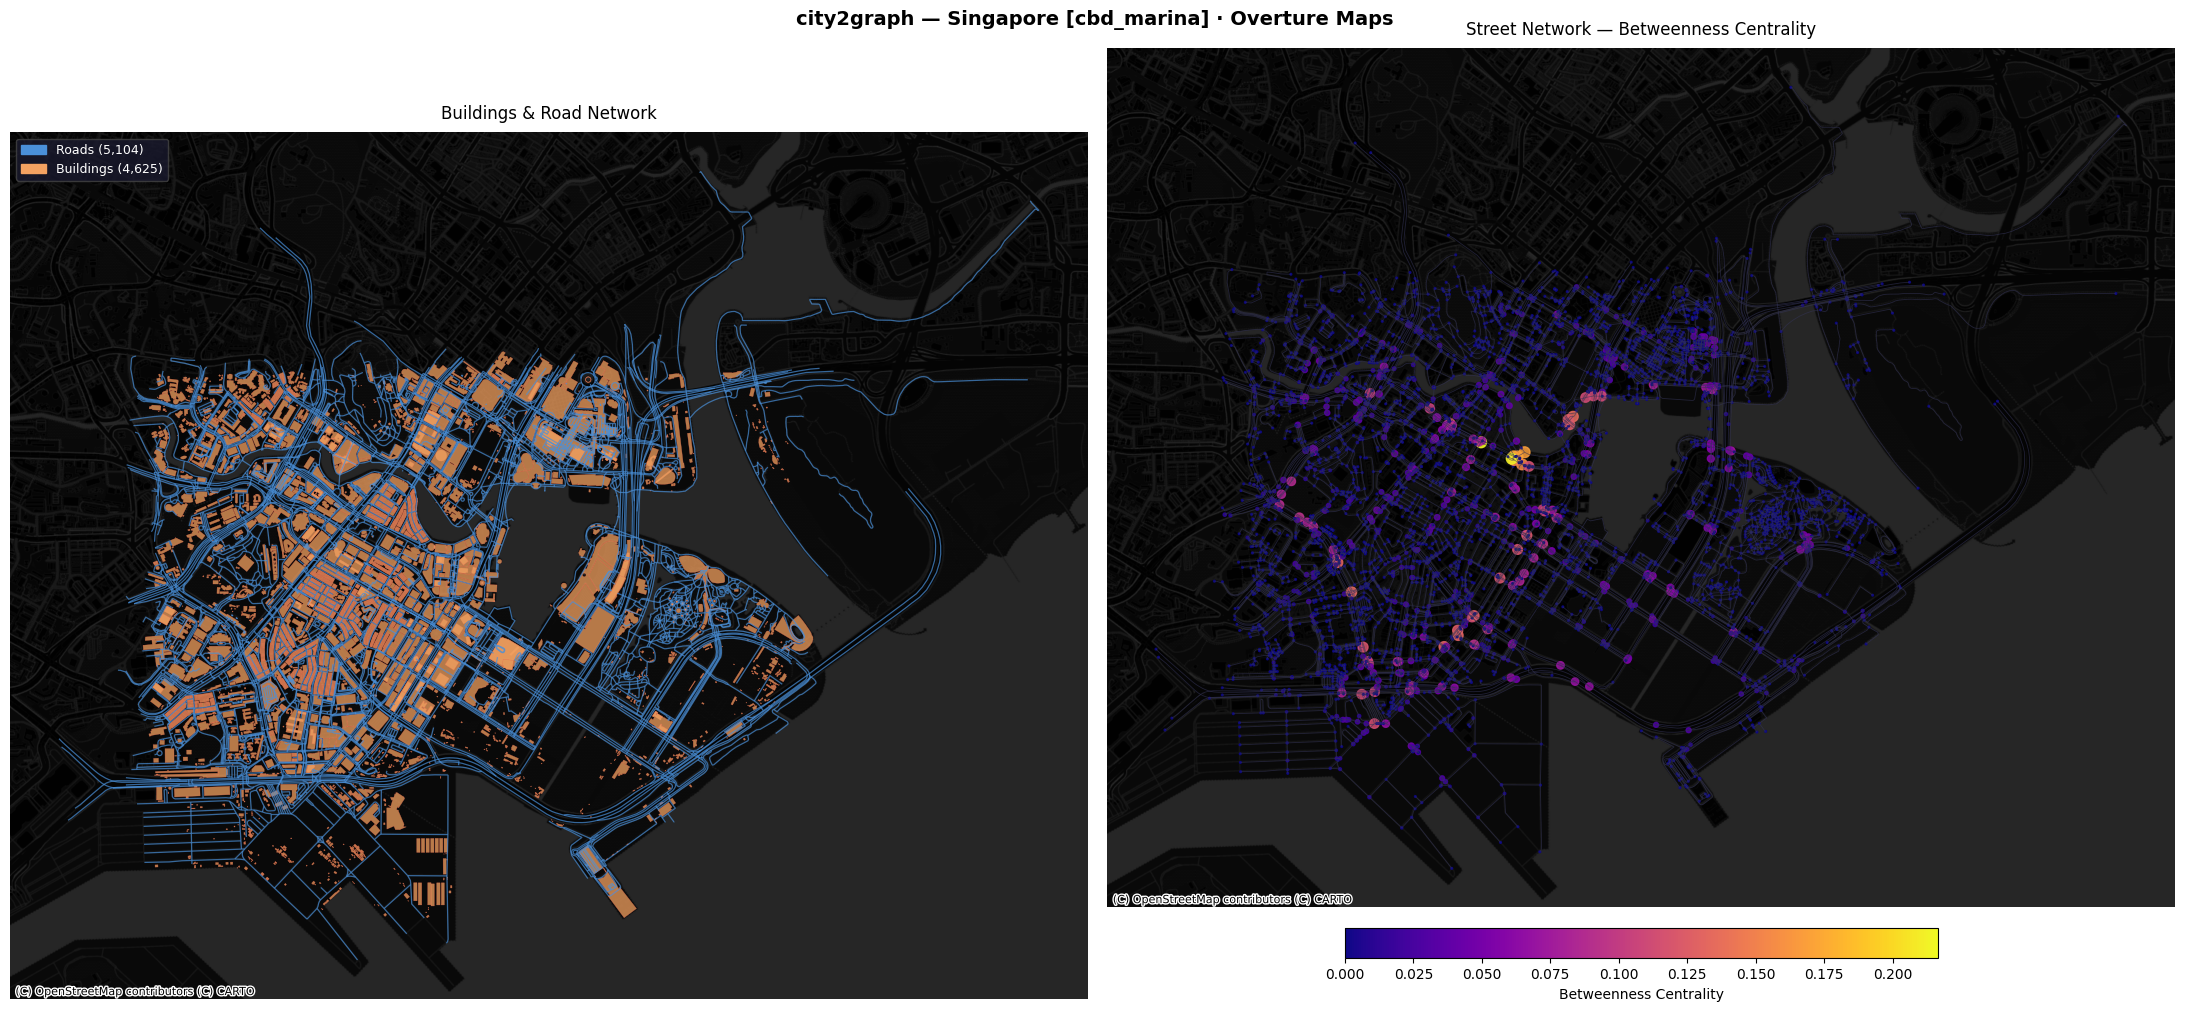

✅ Saved: data/singapore/cbd_marina/01_network_overview.png


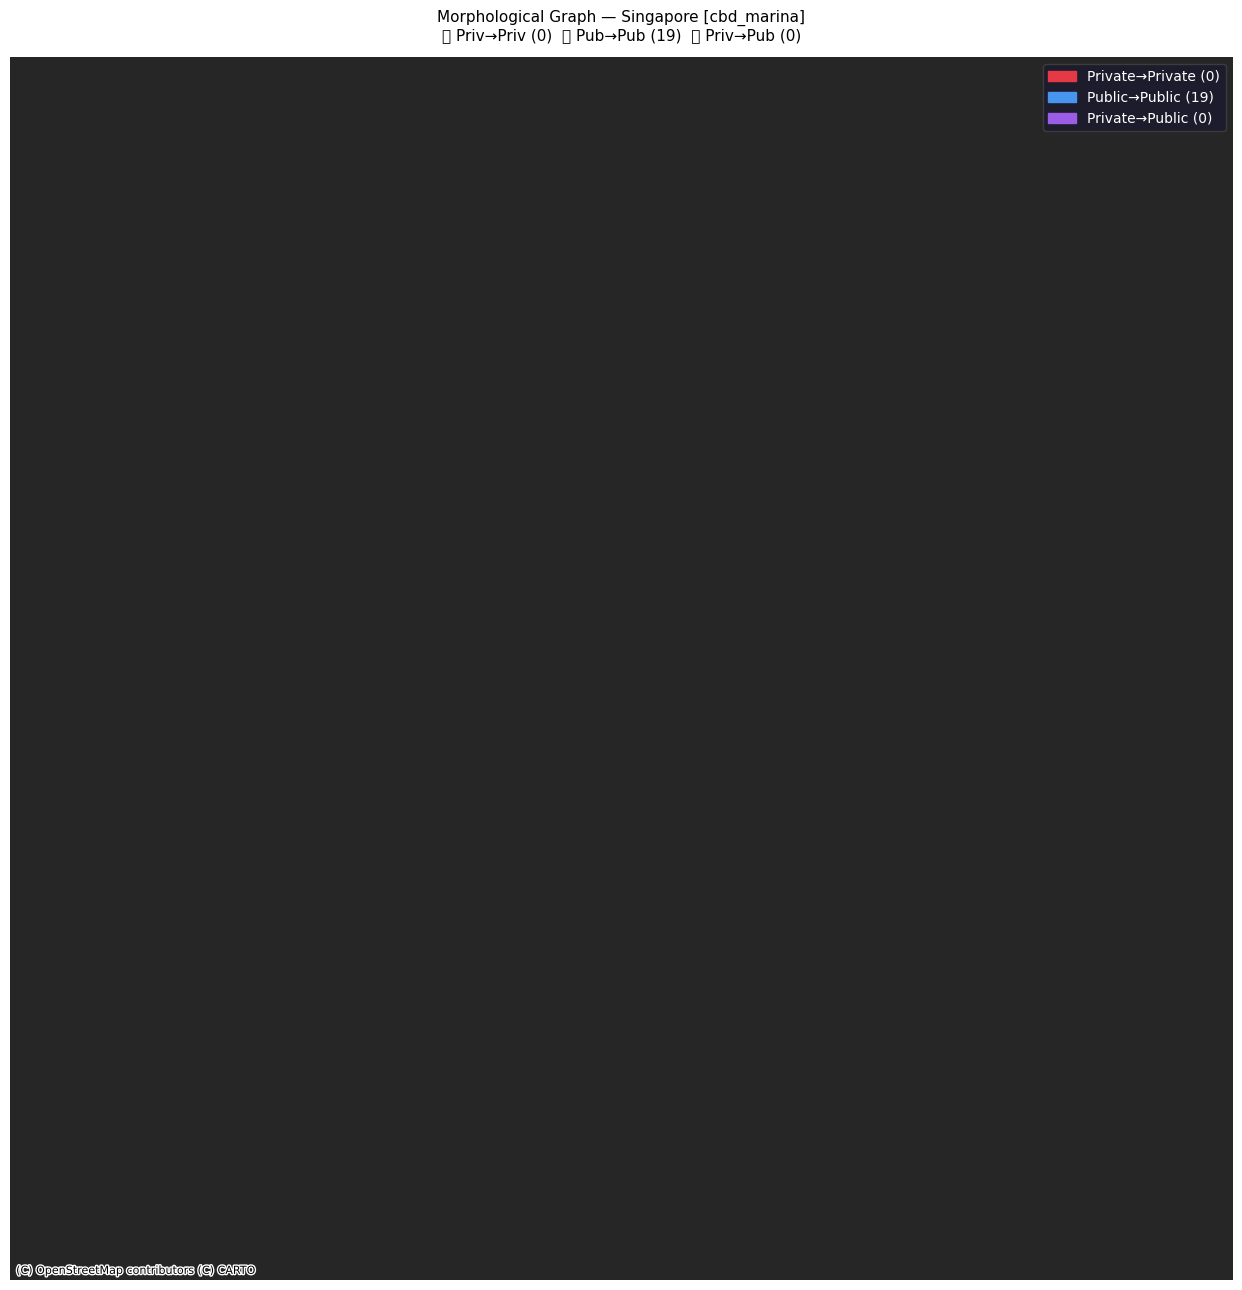

✅ Saved: data/singapore/cbd_marina/02_morphological_graph.png


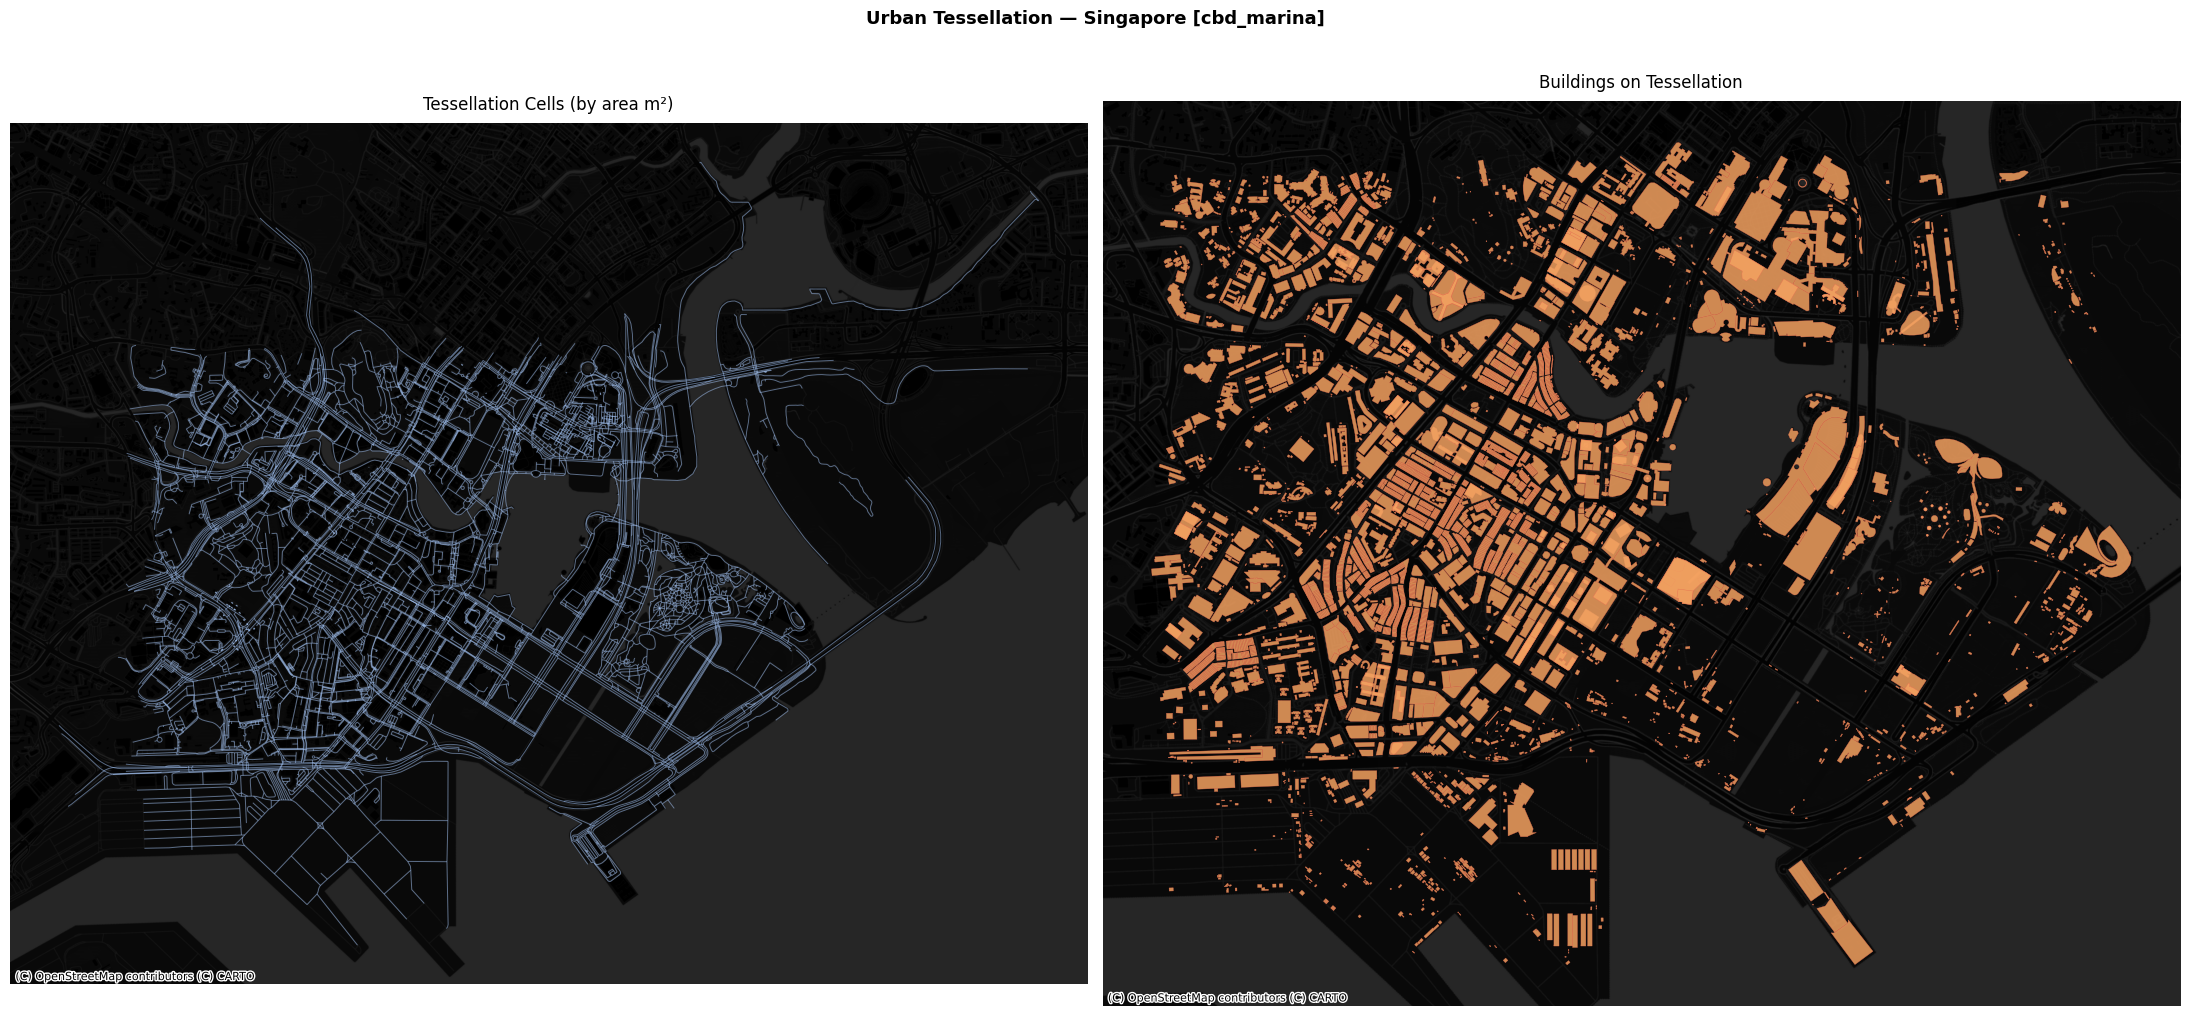

✅ Saved: data/singapore/cbd_marina/03_tessellation.png


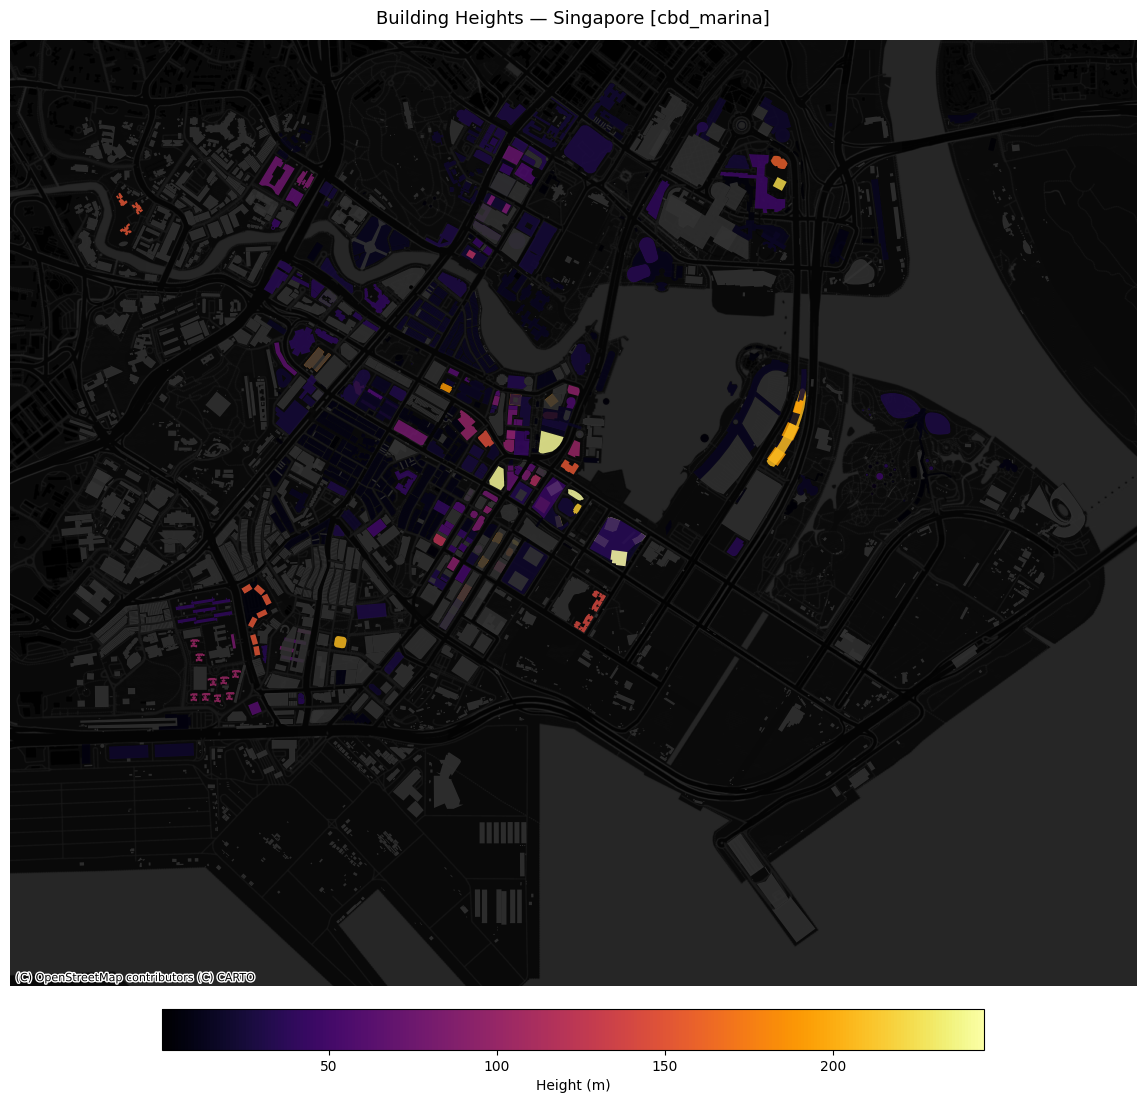

✅ Saved: data/singapore/cbd_marina/04_building_heights.png
Exporting GeoJSON…
   ✅ street_nodes.geojson  (5,782 features)
   ✅ street_edges.geojson  (5,104 features)
   ✅ buildings.geojson  (4,625 features)
   ⏭  Skipped (empty): tessellation.geojson
   ⏭  Skipped (empty): edges_private_private.geojson
   ✅ edges_public_public.geojson  (19 features)
   ⏭  Skipped (empty): edges_private_public.geojson

📁 Outputs: /content/data/singapore/cbd_marina

PyG-related functions: ['gdf_to_pyg', 'is_torch_available', 'nx_to_pyg', 'pyg_to_gdf', 'pyg_to_nx', 'validate_pyg']

⚠️  PyTorch not installed — run: !pip install city2graph[cpu] -q

  SUMMARY — city2graph Singapore [cbd_marina]
  CRS               : SVY21 / EPSG:3414
  Buildings         : 4,625
  Road segments     : 5,104
  Street nodes      : 5,782
  Street edges      : 5,104
  Avg street degree : 1.71
  Morpho radius     : 500 m
  Private nodes     : 0
  Public nodes      : 14
  Priv→Priv edges   : 0
  Pub→Pub edges     : 19
  Priv→Pub edg

In [3]:
# ══════════════════════════════════════════════════════════════════
#  city2graph — Singapore Urban Network Analysis
#  FULL CORRECTED CODE v4 — handles tuple dict keys
# ══════════════════════════════════════════════════════════════════


# ── CELL 1: INSTALL ───────────────────────────────────────────────
!pip install city2graph contextily geopandas matplotlib shapely networkx momepy -q


# ── CELL 2: IMPORTS ───────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as cx
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from shapely.geometry import Point
import city2graph

print(f"city2graph : {city2graph.__version__}")
print(f"geopandas  : {gpd.__version__}")
print(f"networkx   : {nx.__version__}")
print(f"\ncity2graph public API: {[f for f in dir(city2graph) if not f.startswith('_')]}")
print("\n✅ Imports OK")


# ── CELL 3: CONFIG ────────────────────────────────────────────────
BBOXES = {
    "cbd_marina":     [103.8350, 1.2650, 103.8700, 1.2950],
    "orchard":        [103.8150, 1.2950, 103.8450, 1.3150],
    "jurong_east":    [103.7350, 1.3200, 103.7700, 1.3500],
    "tampines":       [103.9350, 1.3450, 103.9700, 1.3750],
    "sentosa":        [103.8270, 1.2420, 103.8620, 1.2630],
    "punggol":        [103.8980, 1.3920, 103.9280, 1.4150],
    "singapore_full": [103.6040, 1.1490, 104.0850, 1.4720],
}
CENTER_POINTS = {
    "cbd_marina":     Point(103.8520, 1.2800),
    "orchard":        Point(103.8300, 1.3050),
    "jurong_east":    Point(103.7520, 1.3350),
    "tampines":       Point(103.9520, 1.3600),
    "sentosa":        Point(103.8440, 1.2530),
    "punggol":        Point(103.9130, 1.4035),
    "singapore_full": Point(103.8198, 1.3521),
}

AREA_NAME     = "cbd_marina"   # ← change this
BBOX          = BBOXES[AREA_NAME]
CENTER_POINT  = CENTER_POINTS[AREA_NAME]
MORPH_DIST    = 500
SINGAPORE_CRS = "EPSG:3414"

EMPTY_GDF = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries([], dtype="geometry"),
    crs=SINGAPORE_CRS
)

print(f"Area         : {AREA_NAME}")
print(f"Bounding box : {BBOX}")
print(f"Center point : {CENTER_POINT}")
print(f"Morph radius : {MORPH_DIST} m")


# ── CELL 4: HELPER FUNCTIONS ──────────────────────────────────────
def key_to_str(k):
    """Normalise any key type to a lowercase string for matching."""
    if isinstance(k, tuple):
        return "_".join(str(p).lower() for p in k)
    return str(k).lower()

def find_key(d, *candidates):
    """
    Find a key in dict d (keys may be strings or tuples).
    Tries exact match first, then substring match on normalised key string.
    """
    keys = list(d.keys())

    # 1. exact match (string keys)
    for c in candidates:
        if c in keys:
            return c

    # 2. substring match on normalised key string
    for c in candidates:
        c_low = c.lower().replace("-", "_")
        for k in keys:
            if c_low in key_to_str(k):
                return k

    return None

def safe_get(d, *candidates):
    """Get value from dict using find_key; return EMPTY_GDF if not found."""
    k = find_key(d, *candidates)
    if k is None:
        return EMPTY_GDF
    v = d[k]
    if not isinstance(v, gpd.GeoDataFrame):
        return EMPTY_GDF
    if len(v) > 0 and v.crs is None:
        v = v.set_crs(SINGAPORE_CRS)
    return v

def ensure_crs(gdf, crs=SINGAPORE_CRS):
    if len(gdf) > 0 and gdf.crs is None:
        return gdf.set_crs(crs)
    return gdf


# ── CELL 5: DOWNLOAD OVERTURE MAPS DATA ───────────────────────────
data_dir = Path(f"./data/singapore/{AREA_NAME}")
data_dir.mkdir(parents=True, exist_ok=True)

buildings_path  = data_dir / f"{AREA_NAME}_building.geojson"
segments_path   = data_dir / f"{AREA_NAME}_segment.geojson"
connectors_path = data_dir / f"{AREA_NAME}_connector.geojson"

if not buildings_path.exists():
    print("Downloading from Overture Maps…")
    city2graph.load_overture_data(
        area         = BBOX,
        types        = ["building", "segment", "connector"],
        output_dir   = str(data_dir),
        prefix       = f"{AREA_NAME}_",
        save_to_file = True,
        return_data  = False,
    )
    print("✅ Download complete")
else:
    print("✅ Using cached data")

buildings_gdf  = gpd.read_file(buildings_path)
segments_gdf   = gpd.read_file(segments_path)
connectors_gdf = gpd.read_file(connectors_path)

print(f"\n📊 Raw dataset:")
print(f"   Buildings  : {len(buildings_gdf):,}")
print(f"   Segments   : {len(segments_gdf):,}")
print(f"   Connectors : {len(connectors_gdf):,}")


# ── CELL 6: REPROJECT TO SVY21 ────────────────────────────────────
buildings_gdf  = buildings_gdf.to_crs(SINGAPORE_CRS)
segments_gdf   = segments_gdf.to_crs(SINGAPORE_CRS)
connectors_gdf = connectors_gdf.to_crs(SINGAPORE_CRS)

print(f"✅ Reprojected to {SINGAPORE_CRS} (SVY21 — metres)")
print(f"\nBuilding columns : {buildings_gdf.columns.tolist()}")
print(f"Segment subtypes : {segments_gdf['subtype'].unique().tolist()}")


# ── CELL 7: FILTER ROADS + PROCESS BARRIERS ───────────────────────
segments_roads = segments_gdf[segments_gdf["subtype"] == "road"].copy()
print(f"Road segments : {len(segments_roads):,}")

print("Processing segments → barrier geometries…")
segments_processed = city2graph.process_overture_segments(
    segments_gdf   = segments_roads,
    get_barriers   = True,
    connectors_gdf = connectors_gdf,
)

geom_types = segments_processed["barrier_geometry"].geom_type.value_counts()
print("Barrier geometry types:")
for gtype, cnt in geom_types.items():
    print(f"  {gtype}: {cnt:,}")


# ── CELL 8: STREET NETWORK GRAPH ──────────────────────────────────
print("Building street network graph…")

nodes_gdf, edges_gdf = city2graph.segments_to_graph(segments_gdf=segments_roads)

print(f"✅ Street network:")
print(f"   Nodes : {len(nodes_gdf):,}")
print(f"   Edges : {len(edges_gdf):,}")

G_street = city2graph.gdf_to_nx(nodes=nodes_gdf, edges=edges_gdf)
G_und    = G_street.to_undirected() if nx.is_directed(G_street) else G_street
avg_deg  = sum(d for _, d in G_und.degree()) / max(G_und.number_of_nodes(), 1)

print(f"\n📈 Street stats:")
print(f"   Avg degree          : {avg_deg:.2f}")
print(f"   Connected components: {nx.number_connected_components(G_und)}")


# ── CELL 9: BETWEENNESS CENTRALITY ────────────────────────────────
print("Computing betweenness centrality…")

largest_cc = max(nx.connected_components(G_und), key=len)
G_main     = G_und.subgraph(largest_cc).copy()
centrality = nx.betweenness_centrality(G_main, k=min(300, len(G_main)), normalized=True)
nodes_gdf["betweenness"] = nodes_gdf.index.map(centrality).fillna(0)

print(f"✅ Done — top 5 nodes:")
print(nodes_gdf.nlargest(5, "betweenness")[["betweenness"]].to_string())


# ── CELL 10: MORPHOLOGICAL GRAPH ──────────────────────────────────
def build_morpho(buildings, segments, center, dist):
    """
    Calls city2graph.morphological_graph and safely unpacks results.
    Handles both string keys and tuple keys e.g. ("private","private").
    Returns: private_nodes, public_nodes, pp_edges, pu_edges, prpu_edges
    """
    print(f"  Calling morphological_graph(distance={dist})…")
    m_nodes, m_edges = city2graph.morphological_graph(
        buildings_gdf = buildings,
        segments_gdf  = segments,
        center_point  = center,
        distance      = dist,
    )

    # ── Print actual keys for debugging ───────────────────────────
    print(f"\n  morpho_nodes keys : {list(m_nodes.keys())}")
    print(f"  morpho_edges keys : {list(m_edges.keys())}")
    print("  Edge counts:")
    for k, v in m_edges.items():
        n = len(v) if isinstance(v, gpd.GeoDataFrame) else "not a GDF"
        print(f"    {k!r:40s} → {n}")

    # ── Unpack nodes ──────────────────────────────────────────────
    priv_n = safe_get(m_nodes, "private", "building", "tess", "priv")
    pub_n  = safe_get(m_nodes, "public",  "street",   "segment", "pub")

    # ── Unpack edges ──────────────────────────────────────────────
    # Handles string keys:  "private_private", "pp", "priv_priv" …
    # Handles tuple keys:   ("private","private"), ("priv","priv") …
    pp_e   = safe_get(m_edges,
                      "private_private", "pp", "priv_priv",
                      "private-private", "p2p", "priv2priv")
    pu_e   = safe_get(m_edges,
                      "public_public",   "pu", "pub_pub",
                      "public-public",   "s2s", "pub2pub", "street")
    prpu_e = safe_get(m_edges,
                      "private_public",  "prpu", "priv_pub",
                      "private-public",  "interface", "priv2pub")

    # ── If safe_get missed tuple keys, brute-force scan ───────────
    def brute_find(d, *hints):
        for k, v in d.items():
            ks = key_to_str(k)
            if all(h in ks for h in hints):
                if isinstance(v, gpd.GeoDataFrame) and len(v) > 0:
                    return v
        return EMPTY_GDF

    if len(pp_e)   == 0: pp_e   = brute_find(m_edges, "priv", "priv")
    if len(pu_e)   == 0: pu_e   = brute_find(m_edges, "pub",  "pub")
    if len(prpu_e) == 0: prpu_e = brute_find(m_edges, "priv", "pub")

    # ── Ensure CRS ────────────────────────────────────────────────
    results = [priv_n, pub_n, pp_e, pu_e, prpu_e]
    results = [ensure_crs(g) for g in results]

    return results


# First attempt at configured radius
print(f"\nBuilding morphological graph — {AREA_NAME} (r={MORPH_DIST}m)…")
private_nodes, public_nodes, pp_edges, pu_edges, prpu_edges = build_morpho(
    buildings_gdf, segments_processed, CENTER_POINT, MORPH_DIST
)

# Auto-retry at 1000 m if private→public is empty
if len(prpu_edges) == 0 and MORPH_DIST < 1000:
    print(f"\n⚠️  No private→public edges at {MORPH_DIST}m — retrying at 1000m…")
    private_nodes, public_nodes, pp_edges, pu_edges, prpu_edges = build_morpho(
        buildings_gdf, segments_processed, CENTER_POINT, 1000
    )

print(f"\n✅ Morphological graph:")
print(f"   Private nodes  : {len(private_nodes):,}")
print(f"   Public nodes   : {len(public_nodes):,}")
print(f"   Priv→Priv      : {len(pp_edges):,}")
print(f"   Pub→Pub        : {len(pu_edges):,}")
print(f"   Priv→Pub       : {len(prpu_edges):,}")
print(f"   TOTAL nodes    : {len(private_nodes)+len(public_nodes):,}")
print(f"   TOTAL edges    : {len(pp_edges)+len(pu_edges)+len(prpu_edges):,}")


# ── CELL 11: BUILDING HEIGHT ANALYSIS ────────────────────────────
print("\n🏙 Building height analysis:")
height_col = next(
    (c for c in ["height", "num_floors", "level", "building:levels"]
     if c in buildings_gdf.columns), None
)

if height_col:
    buildings_gdf["height_num"] = pd.to_numeric(
        buildings_gdf[height_col], errors="coerce"
    )
    high  = (buildings_gdf["height_num"] > 30).sum()
    mid   = ((buildings_gdf["height_num"] > 10) & (buildings_gdf["height_num"] <= 30)).sum()
    low   = (buildings_gdf["height_num"] <= 10).sum()
    nodat = buildings_gdf["height_num"].isna().sum()
    print(f"   Column        : '{height_col}'")
    print(f"   High (>30m)   : {high:,}  HDB towers / condos")
    print(f"   Mid (10–30m)  : {mid:,}  shophouses / walkups")
    print(f"   Low (≤10m)    : {low:,}  landed / industrial")
    print(f"   No data       : {nodat:,}")
else:
    buildings_gdf["height_num"] = np.nan
    print(f"   No height column — available: {buildings_gdf.columns.tolist()}")


# ── CELL 12: PLOT 1 — Network Overview ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
fig.suptitle(
    f"city2graph — Singapore [{AREA_NAME}] · Overture Maps",
    fontsize=14, fontweight="bold", y=0.99
)

ax = axes[0]
ax.set_title("Buildings & Road Network", pad=10, fontsize=12)
segments_roads.to_crs("EPSG:4326").plot(
    ax=ax, color="#4a90d9", linewidth=0.9, alpha=0.7
)
buildings_gdf.to_crs("EPSG:4326").plot(
    ax=ax, facecolor="#f4a261", edgecolor="#e76f51", linewidth=0.3, alpha=0.75
)
cx.add_basemap(ax, crs="EPSG:4326",
               source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=15)
ax.set_axis_off()
ax.legend(
    handles=[
        mpatches.Patch(color="#4a90d9", label=f"Roads ({len(segments_roads):,})"),
        mpatches.Patch(color="#f4a261", label=f"Buildings ({len(buildings_gdf):,})"),
    ],
    loc="upper left", fontsize=9,
    facecolor="#1a1a2e", edgecolor="#444", labelcolor="white"
)

ax = axes[1]
ax.set_title("Street Network — Betweenness Centrality", pad=10, fontsize=12)
edges_gdf.to_crs("EPSG:4326").plot(ax=ax, color="#333355", linewidth=0.6, alpha=0.6)
n_plot = nodes_gdf.to_crs("EPSG:4326").copy()
n_plot["ms"] = (n_plot["betweenness"] * 400 + 1.5).clip(upper=60)
n_plot.plot(
    ax=ax, column="betweenness", cmap="plasma",
    markersize=n_plot["ms"], alpha=0.85, legend=True,
    legend_kwds={"label":"Betweenness Centrality",
                 "orientation":"horizontal","shrink":0.55,"pad":0.02},
)
cx.add_basemap(ax, crs="EPSG:4326",
               source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=15)
ax.set_axis_off()

plt.tight_layout()
out1 = data_dir / "01_network_overview.png"
plt.savefig(out1, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {out1}")


# ── CELL 13: PLOT 2 — Morphological Graph ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 13))
ax.set_title(
    f"Morphological Graph — Singapore [{AREA_NAME}]\n"
    f"🔴 Priv→Priv ({len(pp_edges):,})  "
    f"🔵 Pub→Pub ({len(pu_edges):,})  "
    f"🟣 Priv→Pub ({len(prpu_edges):,})",
    fontsize=11, pad=12
)
cx.add_basemap(ax, crs=SINGAPORE_CRS,
               source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=16)

for gdf, col, alpha, lw in [
    (pp_edges,   "#e63946", 0.55, 0.5),
    (pu_edges,   "#4895ef", 0.70, 0.9),
    (prpu_edges, "#9b5de5", 0.55, 0.6),
]:
    if len(gdf) > 0:
        gdf.plot(ax=ax, color=col, linewidth=lw, alpha=alpha)

if len(private_nodes) > 0:
    private_nodes.plot(ax=ax, facecolor="none",
                       edgecolor="#ffffff22", linewidth=0.3)

ax.legend(
    handles=[
        mpatches.Patch(color="#e63946", label=f"Private→Private ({len(pp_edges):,})"),
        mpatches.Patch(color="#4895ef", label=f"Public→Public ({len(pu_edges):,})"),
        mpatches.Patch(color="#9b5de5", label=f"Private→Public ({len(prpu_edges):,})"),
    ],
    loc="upper right", fontsize=10,
    facecolor="#1a1a2e", edgecolor="#444", labelcolor="white"
)
ax.set_axis_off()
plt.tight_layout()
out2 = data_dir / "02_morphological_graph.png"
plt.savefig(out2, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {out2}")


# ── CELL 14: PLOT 3 — Tessellation ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
fig.suptitle(f"Urban Tessellation — Singapore [{AREA_NAME}]",
             fontsize=13, fontweight="bold")

ax = axes[0]
ax.set_title("Tessellation Cells (by area m²)", pad=10)
if len(private_nodes) > 0:
    private_nodes["area_m2"] = private_nodes.geometry.area
    private_nodes.plot(
        ax=ax, column="area_m2", cmap="YlOrRd",
        alpha=0.7, edgecolor="#ffffff44", linewidth=0.3, legend=True,
        legend_kwds={"label":"Cell area (m²)",
                     "orientation":"horizontal","shrink":0.6,"pad":0.02},
    )
segments_roads.plot(ax=ax, color="#aaccff", linewidth=0.7, alpha=0.5)
cx.add_basemap(ax, crs=SINGAPORE_CRS,
               source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=16)
ax.set_axis_off()

ax = axes[1]
ax.set_title("Buildings on Tessellation", pad=10)
if len(private_nodes) > 0:
    private_nodes.plot(ax=ax, facecolor="#2a4a6a",
                       edgecolor="#4488aa", linewidth=0.4, alpha=0.5)
buildings_gdf.plot(ax=ax, facecolor="#f4a261",
                   edgecolor="#e76f51", linewidth=0.3, alpha=0.85)
cx.add_basemap(ax, crs=SINGAPORE_CRS,
               source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=16)
ax.set_axis_off()

plt.tight_layout()
out3 = data_dir / "03_tessellation.png"
plt.savefig(out3, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {out3}")


# ── CELL 15: PLOT 4 — Building Heights ────────────────────────────
if buildings_gdf["height_num"].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_title(f"Building Heights — Singapore [{AREA_NAME}]",
                 fontsize=13, pad=12)
    buildings_gdf.plot(
        ax=ax, column="height_num", cmap="inferno",
        edgecolor="none", alpha=0.85, legend=True,
        missing_kwds={"color":"#333333","label":"No data"},
        legend_kwds={"label":"Height (m)",
                     "orientation":"horizontal","shrink":0.6,"pad":0.02},
    )
    cx.add_basemap(ax, crs=SINGAPORE_CRS,
                   source=cx.providers.CartoDB.DarkMatterNoLabels, zoom=16)
    ax.set_axis_off()
    plt.tight_layout()
    out4 = data_dir / "04_building_heights.png"
    plt.savefig(out4, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✅ Saved: {out4}")
else:
    print("⚠️  No height data — skipping height plot")


# ── CELL 16: EXPORT GEOJSON ───────────────────────────────────────
def safe_export(gdf, path):
    if gdf is None or len(gdf) == 0:
        print(f"   ⏭  Skipped (empty): {path.name}")
        return
    out = gdf.to_crs("EPSG:4326").copy()
    for col in list(out.columns):
        if col == "geometry":
            continue
        try:
            out[col] = out[col].astype(str)
        except Exception:
            out.drop(columns=[col], inplace=True)
    out.to_file(path, driver="GeoJSON")
    print(f"   ✅ {path.name}  ({len(out):,} features)")

print("Exporting GeoJSON…")
safe_export(nodes_gdf,     data_dir / "street_nodes.geojson")
safe_export(edges_gdf,     data_dir / "street_edges.geojson")
safe_export(buildings_gdf, data_dir / "buildings.geojson")
safe_export(private_nodes, data_dir / "tessellation.geojson")
safe_export(pp_edges,      data_dir / "edges_private_private.geojson")
safe_export(pu_edges,      data_dir / "edges_public_public.geojson")
safe_export(prpu_edges,    data_dir / "edges_private_public.geojson")
print(f"\n📁 Outputs: {data_dir.resolve()}")


# ── CELL 17: PYTORCH GEOMETRIC (optional) ─────────────────────────
try:
    import torch
    pyg_fns = [f for f in dir(city2graph)
               if "pyg" in f.lower() or "torch" in f.lower() or "geometric" in f.lower()]
    print(f"\nPyG-related functions: {pyg_fns}")

    if hasattr(city2graph, "gdf_to_pyg"):
        data_homo = city2graph.gdf_to_pyg(nodes=nodes_gdf, edges=edges_gdf)
        print(f"✅ Homogeneous PyG: {data_homo}")
    elif hasattr(city2graph, "to_pytorch_geometric"):
        data_homo = city2graph.to_pytorch_geometric(nodes_gdf, edges_gdf)
        print(f"✅ Homogeneous PyG: {data_homo}")
    else:
        print("⚠️  No PyG conversion function found in this version.")

except ImportError:
    print("\n⚠️  PyTorch not installed — run: !pip install city2graph[cpu] -q")


# ── CELL 18: SUMMARY ──────────────────────────────────────────────
print("\n" + "="*58)
print(f"  SUMMARY — city2graph Singapore [{AREA_NAME}]")
print("="*58)
print(f"  CRS               : SVY21 / EPSG:3414")
print(f"  Buildings         : {len(buildings_gdf):,}")
print(f"  Road segments     : {len(segments_roads):,}")
print(f"  Street nodes      : {len(nodes_gdf):,}")
print(f"  Street edges      : {len(edges_gdf):,}")
print(f"  Avg street degree : {avg_deg:.2f}")
print(f"  Morpho radius     : {MORPH_DIST} m")
print(f"  Private nodes     : {len(private_nodes):,}")
print(f"  Public nodes      : {len(public_nodes):,}")
print(f"  Priv→Priv edges   : {len(pp_edges):,}")
print(f"  Pub→Pub edges     : {len(pu_edges):,}")
print(f"  Priv→Pub edges    : {len(prpu_edges):,}")
print(f"  Total nodes       : {len(private_nodes)+len(public_nodes):,}")
print(f"  Total edges       : {len(pp_edges)+len(pu_edges)+len(prpu_edges):,}")
print("="*58)
print(f"\n📁 {data_dir.resolve()}")
for f in sorted(data_dir.glob("0*.png")):
    print(f"   🖼  {f.name}")
for f in sorted(data_dir.glob("*.geojson")):
    print(f"   📄 {f.name}")